In [ ]:
import base64
import io
import os
import time
import uuid
from typing import List, Dict, Union
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from pydantic import BaseModel, Field
import cv2 as cv
import torch
import torchvision
import torch.nn.functional as F
import psycopg2
import gc

# Helper Functions

In [ ]:
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)

    if mask.ndim > 2:
        # If the first dimension is 1 (e.g. 1, H, W), squeeze it
        mask = np.squeeze(mask)

    # 3. Convert Boolean (True/False) to uint8 (0-255)
    # OpenCV CANNOT handle booleans
    if mask.dtype == bool:
        mask = (mask * 255).astype(np.uint8)
    else:
        mask = mask.astype(np.uint8)

    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

In [ ]:
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

In [ ]:
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

In [ ]:
def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    box_coords = box_coords if box_coords is not None else []
    scores = scores if scores is not None else []
    # Iterate through masks and scores
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)

        # Show the mask
        show_mask(mask, plt.gca(), borders=borders)

        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())

        if box_coords is not None:
            # --- THE FIX IS HERE ---
            # We must pass only the i-th box, not the whole list
            # We added a safety check in case there is only 1 box for multiple masks
            if len(box_coords) == len(masks):
                show_box(box_coords[i], plt.gca())
            else:
                # Fallback: if there is only 1 box for 3 masks (common in SAM multimask mode)
                show_box(box_coords[0], plt.gca())
        if len(scores) > 1:
            value = np.round(score, decimals=3)
            plt.title(f"Mask {i+1}, Score: {value}", fontsize=18)

        plt.axis('off')
        plt.show()

# Grounded - SAM

In [ ]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


In [ ]:
# !{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-493lfddo
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-493lfddo
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.3 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-cp312-cp312-linux_x86_64.whl size=183669 sha256=0909c543b5664228b1b5d532b3b7579c4e1092d630f2ac7562ad7f741050c71d
  Stored in directory: /tmp/pip-ephem-wheel-cache-500oyxjl/wheels/25/a3/8a/abd69dc6a6926b5e75c24810afac36c7b49b5c0f8a100147d6
  Created wheel for iopath: filename=iopath-0.1.10-py3-non

In [ ]:
!{sys.executable} -m pip install transformers torch pillow requests

In [ ]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

sam2_checkpoint = "../checkpoints/sam2.1_hiera_base_plus.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"

model_id = "IDEA-Research/grounding-dino-tiny"


In [ ]:
!mkdir -p ../checkpoints/
!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_base_plus.pt

--2026-06-26 13:33:37--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_base_plus.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.81, 13.249.182.33, 13.249.182.62, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 323606802 (309M) [application/vnd.snesdev-page-table]
Saving to: ‘../checkpoints/sam2.1_hiera_base_plus.pt’

sam2.1_hiera_base_p 100%[===================>] 308.62M   223MB/s    in 1.4s    

2026-06-26 13:33:39 (223 MB/s) - ‘../checkpoints/sam2.1_hiera_base_plus.pt’ saved [323606802/323606802]



In [ ]:
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [ ]:
class SAM_service():
    def __init__(self, checkpoint, model_cfg, d_model_id, device):
        self.device = device

        # Load SAM 2
        self.sam2_model = build_sam2(model_cfg, checkpoint, device=device)
        self.predictor = SAM2ImagePredictor(self.sam2_model)

        # Load Grounding DINO
        self.processor = AutoProcessor.from_pretrained(d_model_id)
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(d_model_id).to(device)

        # State tracking to avoid re-encoding the same image
        self._current_image_ref = None

    def _prepare_image(self, image: Image.Image):
        """Helper to convert PIL to Numpy array for SAM"""
        return np.array(image.convert("RGB"))

    def _set_image_if_needed(self, image: Image.Image):
        """
        Optimization: Only runs the heavy image encoder if the image has changed.
        """
        # Compare object references or add an ID check if needed.
        # For simple flows, checking if it's the same object in memory is a good start.
        if self._current_image_ref is not image:
            self.predictor.set_image(image)
            self._current_image_ref = image
            # Clear memory after encoding (SAM caches features internally)
            gc.collect()

    def segment_image(self, image: Image.Image, boxes=None, multimask=False):
        # Set Image (Only if new)
        self._set_image_if_needed(image)

        # Predict
        masks, scores, logits = self.predictor.predict(
            box=boxes,
            multimask_output=multimask,
        )

        # CPU Cleanup
        gc.collect()

        return masks, scores, logits

    def segment_with_prompt(self, image: Image.Image, prompt: str, multimask=False):

        if isinstance(image, Image.Image):
            if image.mode != "RGB":
                image = image.convert("RGB")
        else:
            raise TypeError("Expected PIL.Image.Image")

        # Grounding DINO
        inputs = self.processor(
                images=image,
                text=prompt,
                return_tensors="pt"
                ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]])
        results = self.processor.image_processor.post_process_object_detection(
            outputs,
            threshold=0.35,
            target_sizes=target_sizes
        )[0]

        # Cleanup DINO tensors immediately to free RAM for SAM
        del inputs, outputs
        gc.collect()

        # Check if DINO found anything
        if len(results['boxes']) == 0:
            print(f"No objects found for prompt: {prompt}")
            return [], [], []

        best_box = results['boxes'].cpu().numpy()

        # Cleanup results
        del results

        cleaned_boxes = self.remove_duplicates(best_box, iou_threshold=0.75)
        gc.collect()

        # SAM 2
        # We pass the boxes directly. SAM 2 handles (N, 4) arrays fine.
        masks, scores, logits = self.segment_image(image, boxes=cleaned_boxes, multimask=multimask)

        return masks, cleaned_boxes, scores

    def calculate_iou(self, box, boxes):
        """
        Calculates IoU of one box against an array of boxes.
        """
        # Determine coordinates of the intersection rectangles
        x1 = np.maximum(box[0], boxes[:, 0])
        y1 = np.maximum(box[1], boxes[:, 1])
        x2 = np.minimum(box[2], boxes[:, 2])
        y2 = np.minimum(box[3], boxes[:, 3])

        # Calculate intersection area
        intersection_area = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)

        # Calculate union area
        box_area = (box[2] - box[0]) * (box[3] - box[1])
        boxes_area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        union_area = box_area + boxes_area - intersection_area

        # Avoid division by zero
        return intersection_area / (union_area + 1e-6)

    def remove_duplicates(self, boxes, iou_threshold=0.85):
        """
        Removes duplicate boxes based on IoU threshold.
        """
        if len(boxes) == 0:
            return []

        # We use indices to keep track of which boxes to keep
        indices = np.arange(len(boxes))
        keep = []

        while len(indices) > 0:
            # Pick the first box in the list (current "best")
            current_idx = indices[0]
            keep.append(current_idx)

            # Compare this box to the remaining boxes
            remaining_indices = indices[1:]
            current_box = boxes[current_idx]
            remaining_boxes = boxes[remaining_indices]

            # Calculate IoU
            ious = self.calculate_iou(current_box, remaining_boxes)

            # Keep only boxes that have low overlap (IoU < threshold)
            # We find indices where IoU is LESS than threshold to keep them for next round
            under_threshold_indices = np.where(ious < iou_threshold)[0]

            # Update indices list (map back to original remaining_indices)
            indices = remaining_indices[under_threshold_indices]

        return boxes[keep]

    def resegment(self, image: Image.Image, pos_points, neg_points, boxes=None):
        """
        Refines the mask based on user clicks.
        """
        # Combine points
        points = []
        labels = []

        if pos_points:
            points.extend(pos_points)
            labels.extend([1] * len(pos_points)) # 1 = Positive

        if neg_points:
            points.extend(neg_points)
            labels.extend([0] * len(neg_points)) # 0 = Negative

        points_np = np.array(points)
        labels_np = np.array(labels)

        # Set Image (Checks if it's the same image as before to save time)
        self._set_image_if_needed(image)

        # Predict using points
        masks, scores, logits = self.predictor.predict(
            point_coords=points_np,
            point_labels=labels_np,
            box=boxes,
            multimask_output=False,
        )

        gc.collect()
        return masks, scores, logits

    def get_segmented_image(self, image: Image.Image, mask):
        """
        Applies the mask, CROPS the empty space, and returns a transparent PNG.
        """
        image_np = self._prepare_image(image)

        # Handle SAM dimensions: Ensure we have (H, W)
        if len(mask.shape) > 2:
            mask = mask[0]

        # Create RGBA
        h, w, c = image_np.shape
        rgba_image = np.zeros((h, w, 4), dtype=np.uint8)

        # Copy RGB channels
        rgba_image[..., :3] = image_np

        # Create Binary Mask
        binary_mask = mask > 0
        rgba_image[..., 3] = np.where(binary_mask, 255, 0)

        # --- NEW: CROP LOGIC ---
        # 1. Find indices where the mask is True
        # np.where returns (row_indices, col_indices)
        y_indices, x_indices = np.where(binary_mask)

        # 2. Safety Check: If mask is empty, return the original transparent image
        if len(y_indices) == 0 or len(x_indices) == 0:
            return Image.fromarray(rgba_image)

        # 3. Calculate the Bounding Box
        top = y_indices.min()
        bottom = y_indices.max()
        left = x_indices.min()
        right = x_indices.max()

        # 4. Crop the Numpy Array
        # Slice format: [start_row : end_row, start_col : end_col]
        # We add +1 because Python slicing excludes the upper bound
        cropped_rgba = rgba_image[top:bottom+1, left:right+1]

        return Image.fromarray(cropped_rgba)

    def squeeze_mask(self, mask):
        """
        Removes single-dimensional entries from the mask array.
        """
        M = mask.shape[0]
        weights = np.arange(1, M + 1)[:, np.newaxis, np.newaxis]
        Y = np.sum(mask * weights, axis=0)
        return Y


In [ ]:
sam = SAM_service(sam2_checkpoint, model_cfg, model_id, device=device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

# OpenCLIP

In [ ]:
!{sys.executable} -m pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00


In [ ]:
import open_clip

_device = "cuda" if torch.cuda.is_available() else "cpu"
_model = None
_preprocess = None
_tokenizer = None

def get_model():
    """Lazy-load the OpenCLIP model."""
    global _model, _preprocess, _tokenizer
    if _model is None:
        print("🔹 Loading OpenCLIP model...")
        _model, _, _preprocess = open_clip.create_model_and_transforms(
            'ViT-B-32',
            pretrained='laion2b_s34b_b79k'
        )
        _tokenizer = open_clip.get_tokenizer('ViT-B-32')
        _model = _model.to(_device)
        _model.eval()
    return _model, _preprocess, _tokenizer

def get_image_embedding(image):
    """
    image_data: can be raw bytes or base64 string
    """
    # If base64 encoded, decode it
    # if isinstance(image_data, str):
    #     image_data = base64.b64decode(image_data)

    model, preprocess, _ = get_model()
    # image = Image.open(io.BytesIO(image_data)).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(_device)

    with torch.no_grad():
        embedding = model.encode_image(image_tensor)
        embedding /= embedding.norm(dim=-1, keepdim=True)

    return embedding.float().cpu().numpy()

def get_text_embedding(texts: list[str]):
    model, _, tokenizer = get_model()
    tokens = tokenizer(texts).to(_device)
    with torch.no_grad():
        embeddings = model.encode_text(tokens)
        embeddings /= embeddings.norm(dim=-1, keepdim=True)
    return embedding.float().cpu().numpy()

def cosine_similarity(emb1, emb2):
    emb1 = torch.tensor(emb1)
    emb2 = torch.tensor(emb2)
    return F.cosine_similarity(emb1, emb2).item()

# for debugging without faiss
def get_KNN_cosine_similarity(query_emb, embeddings, k=5):
    query_emb = torch.tensor(query_emb)
    embeddings = torch.tensor(embeddings)
    similarities = F.cosine_similarity(query_emb, embeddings)
    top_k_indices = torch.topk(similarities, k).indices.tolist()
    return top_k_indices

def get_embeddings(data, mode="image"):
    if mode == "image":
        return get_image_embedding(data)
    elif mode == "text":
        return get_text_embedding(data)
    else:
        raise ValueError("Invalid mode: must be 'image' or 'text'")

# FAISS

In [ ]:
!{sys.executable} -m pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 72.6 MB/s eta 0:00:00


In [ ]:
# faiss_manager.py
import os
import faiss
import numpy as np

EMBEDDING_DIM = 512
FAISS_DIR = "/faiss_indexes"
os.makedirs(FAISS_DIR, exist_ok=True)

UPLOADED_IMGS_INDEX_PATH = os.path.join(FAISS_DIR, "faiss_uploaded_imgs.index")
STORED_ITEMS_INDEX_PATH = os.path.join(FAISS_DIR, "faiss_stored_items.index")

# ------------------------------------------------
# Global in‑memory indexes (dictionary)
# ------------------------------------------------
_loaded_indexes = {}

def get_index_path(index_type: str) -> str:
    """Returns path to the appropriate FAISS index."""
    if index_type == "uploaded_img":
        return UPLOADED_IMGS_INDEX_PATH
    elif index_type == "stored_item":
        return STORED_ITEMS_INDEX_PATH
    else:
        raise ValueError("Invalid index_type. Use 'uploaded_img' or 'stored_item'.")

def load_faiss_indexes():
    """
    Load all existing FAISS indexes into memory.
    Call this once before any adding or searching.
    """
    for index_type in ["uploaded_img", "stored_item"]:
        path = get_index_path(index_type)
        if os.path.exists(path):
            print(f"Loading existing FAISS index: {path}")
            _loaded_indexes[index_type] = faiss.read_index(path)
        else:
            print(f"Creating new FAISS index: {path}")
            _loaded_indexes[index_type] = faiss.IndexFlatL2(EMBEDDING_DIM)

def save_faiss_indexes():
    """
    Save all in‑memory FAISS indexes to disk.
    Call this once at the very end (or periodically for safety).
    """
    for index_type, index in _loaded_indexes.items():
        path = get_index_path(index_type)
        faiss.write_index(index, path)
        print(f"Saved FAISS index: {path}")

# ------------------------------------------------
# Core functions now work purely in memory
# ------------------------------------------------
def add_embedding(embedding: np.ndarray, index_type: str):
    """
    Add an embedding to the in‑memory FAISS index.
    Returns the FAISS ID of the newly added vector.
    """
    if index_type not in _loaded_indexes:
        raise RuntimeError(
            f"FAISS index '{index_type}' not loaded. Call load_faiss_indexes() first."
        )
    index = _loaded_indexes[index_type]

    # Ensure correct shape and dtype
    embedding = np.asarray(embedding, dtype=np.float32)
    if embedding.ndim == 1:
        embedding = np.expand_dims(embedding, axis=0)

    index.add(embedding)
    faiss_id = index.ntotal - 1
    # NO saving to disk here – stays in memory
    return faiss_id


def search_top_k_similar(embedding: np.ndarray, index_type: str, k=5):
    """
    Search the in‑memory FAISS index for similar embeddings.
    """
    if index_type not in _loaded_indexes:
        raise RuntimeError(
            f"FAISS index '{index_type}' not loaded. Call load_faiss_indexes() first."
        )
    index = _loaded_indexes[index_type]

    embedding = np.asarray(embedding, dtype=np.float32)
    if embedding.ndim == 1:
        embedding = np.expand_dims(embedding, axis=0)

    distances, indices = index.search(embedding, k)
    return distances, indices

# PostgresSQL

In [ ]:


DB_HOST = 'fitfinder-csed-fitfindercsed.d.aivencloud.com'
DB_PORT = '18509'
DB_NAME = 'fitfinderdb'
DB_USER = 'avnadmin'
DB_PASSWORD = 'AVNS_qqk5QuYiTYxMqMZfm2F'


import psycopg2
from psycopg2 import pool

# ------------------------------------------------------------
# POOL SETUP – call once, at module level, before any processing
# ------------------------------------------------------------
DB_POOL = pool.SimpleConnectionPool(
    1,                          # min connections
    3,                          # max connections (≤ your DB's connection limit)
    host=DB_HOST,
    port=DB_PORT,
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    sslmode="require"
)

def get_connection():
    """Get a connection from the pool (replaces your old get_connection)."""
    return DB_POOL.getconn()

def release_connection(conn):
    """Return a connection to the pool instead of closing it."""
    DB_POOL.putconn(conn)

# ------------------------------------------------------------
# REWRITTEN DATABASE FUNCTIONS (using pool + release)
# ------------------------------------------------------------
def create_table():
    conn = get_connection()
    try:
        cur = conn.cursor()
        cur.execute("""
        CREATE TABLE IF NOT EXISTS stored_items (
            item_id SERIAL PRIMARY KEY,
            item_faiss_id BIGINT,
            title TEXT,
            price REAL,
            currency TEXT,
            item_weburl TEXT,
            imageurl TEXT,
            category TEXT,
            description TEXT,
            source TEXT,
            embedded BOOLEAN DEFAULT TRUE
        );
        """)
        conn.commit()
        cur.close()
    except Exception:
        conn.rollback()
        raise
    finally:
        release_connection(conn)   # <-- never close, always release

def insert_item_metadata(
    title, price, currency,
    item_web_url, image_url, category,
    description, source
):
    conn = get_connection()
    try:
        cur = conn.cursor()
        cur.execute(
            """
            INSERT INTO stored_items
                (category, currency, description, embedded, imageurl,
                 item_weburl, price, source, title)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
            RETURNING item_id;
            """,
            (
                category, currency, description, True,
                image_url, item_web_url, price,
                source, title
            )
        )
        new_id = cur.fetchone()[0]
        conn.commit()
        cur.close()
        return new_id
    except Exception:
        conn.rollback()
        raise
    finally:
        release_connection(conn)

def insert_product_image(product_id, image_url, faiss_id):
    conn = get_connection()
    try:
        cur = conn.cursor()
        cur.execute(
            """
            INSERT INTO product_images (product_id, image_url, faiss_id)
            VALUES (%s, %s, %s)
            """,
            (product_id, image_url, faiss_id)
        )
        conn.commit()
        cur.close()
    except Exception:
        conn.rollback()
        raise
    finally:
        release_connection(conn)

def add_FIASS(item_id, faiss_id):
    conn = get_connection()
    try:
        cur = conn.cursor()
        cur.execute(
            """
            INSERT INTO item_vector (vector_id, item_id)
            VALUES (%s, %s);
            """,
            (faiss_id, item_id)
        )
        conn.commit()
        cur.close()
    except Exception:
        conn.rollback()
        raise
    finally:
        release_connection(conn)

def product_already_exists(item_web_url: str) -> bool:
    """True if a product with this URL already exists in stored_items."""
    conn = get_connection()
    try:
        cur = conn.cursor()
        cur.execute(
            "SELECT item_id FROM stored_items WHERE item_weburl = %s LIMIT 1",
            (item_web_url,)
        )
        exists = cur.fetchone() is not None
        cur.close()
        return exists
    finally:
        release_connection(conn)


# Upload Data From ZIP File

In [ ]:
import traceback

In [ ]:
!unzip -q asos.zip -d /content/raw

In [ ]:
import json
import glob
import httpx
from pathlib import Path


http_client = httpx.AsyncClient(timeout=30.0)

failed_products = []

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36",
    "Accept": "image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.asos.com/",       # crucial
    "Sec-Fetch-Dest": "image",
    "Sec-Fetch-Mode": "no-cors",
    "Sec-Fetch-Site": "cross-site",
}

async def generate_embedding(image_url, text, show_image=False, show_segment=False):
    try:
        response = await http_client.get(image_url, headers=HEADERS)

        response.raise_for_status()

        image_bytes = response.content
        image = Image.open(io.BytesIO(image_bytes))
        if show_image:
            plt.figure(figsize=(10, 10))
            plt.imshow(image)
            plt.axis('off')
            plt.show()

    except httpx.HTTPStatusError as e:
        print(f"---  ERROR: HTTP error while downloading: {e} ---")
        return
    except httpx.RequestError as e:
        print(f"---  ERROR: Network error while downloading: {e} ---")
        return
    except Exception as e:
        print(f"---  ERROR: Unexpected error while downloading: {e} ---")
        return


    if text[-1] != '.':
      text += '.'

    masks = None
    embeddings = []

    try:
      masks , boxes, scores= sam.segment_with_prompt(image, text.lower())


      segmented_items = []

      for mask in masks:
        segmented_image = sam.get_segmented_image(image, mask)
        if show_segment:
          plt.figure(figsize=(10, 10))
          plt.imshow(segmented_image)
          plt.title(f"Category: {text}")
          plt.axis('off')
          plt.show()

        segmented_items.append(segmented_image)
        embeddings.append(get_image_embedding(segmented_image))

    except Exception as e:
      print(f"---  ERROR: {e} ---")
      traceback.print_exc()
      return


    return embeddings


RAW_DATA_PATH = "raw/raw/*.json"

def truncate(s, max_len=255):
    if s is None:
        return None
    return s[:max_len]

async def process_items():

    print("📌 Processing JSON files...")
    for file_path in glob.glob(RAW_DATA_PATH):
        print(f"➡️ Reading: {file_path}")

        with open(file_path, "r") as f:
            item = json.load(f)

            for product in item:
              # --- Generate embedding (replace later with real model)
              embedding = await generate_embedding(product['image_url'], product['category'])
              if embedding is None:
                failed_products.append(product['image_url'])
                continue

                # --- Insert metadata into PostgreSQL
              item_id = insert_item_metadata(
                  title=truncate(product['title']),
                  price=float(product['price']),
                  currency=truncate(product['currency']),
                  item_web_url=truncate(product['item_web_url']),
                  image_url=truncate(product['image_url']),
                  category=truncate(product['category']),
                  description=product['description'],  # text is fine
                  source=truncate(product['source'])
              )

              for emb in embedding:
                faiss_id = add_embedding(emb, index_type="stored_item")
                add_FIASS(item_id, faiss_id)
                print(f"   ✔ Stored item with FAISS ID {faiss_id}")



    print("🎉 Done!")

In [ ]:
import json
import glob
import httpx
from pathlib import Path

RAW_DATA_PATH = "/content/raw/*.json"
count = 0
for file_path in glob.glob(RAW_DATA_PATH):
        prodcuts_count = 0
        length = 0
        with open(file_path, "r") as f:
            data = json.load(f)
            length = len(data)
            for product in data:
                prodcuts_count += 1
        print(f"➡️ Reading: {file_path}, {count+1}, products; {prodcuts_count}, length: {length}")
        count += 1


➡️ Reading: /content/raw/Jumpers.json, 1, products; 289, length: 289
➡️ Reading: /content/raw/Caps.json, 2, products; 12, length: 12
➡️ Reading: /content/raw/Blouses.json, 3, products; 91, length: 91
➡️ Reading: /content/raw/Suit Trousers.json, 4, products; 228, length: 228
➡️ Reading: /content/raw/Ties.json, 5, products; 17, length: 17
➡️ Reading: /content/raw/Jeans.json, 6, products; 453, length: 453
➡️ Reading: /content/raw/Swim Trunks.json, 7, products; 17, length: 17
➡️ Reading: /content/raw/Hair Clips.json, 8, products; 2, length: 2
➡️ Reading: /content/raw/Bracelets.json, 9, products; 16, length: 16
➡️ Reading: /content/raw/Wellies.json, 10, products; 1, length: 1
➡️ Reading: /content/raw/Blazers.json, 11, products; 57, length: 57
➡️ Reading: /content/raw/Trunks.json, 12, products; 19, length: 19
➡️ Reading: /content/raw/Chinos.json, 13, products; 25, length: 25
➡️ Reading: /content/raw/Bodies.json, 14, products; 27, length: 27
➡️ Reading: /content/raw/Pyjama Tops.json, 15, prod

Fetching: https://images.asos-media.com/products/asos-design-knitted-oversized-jumper-with-carrot-design-in-peach/22446508-1-peach


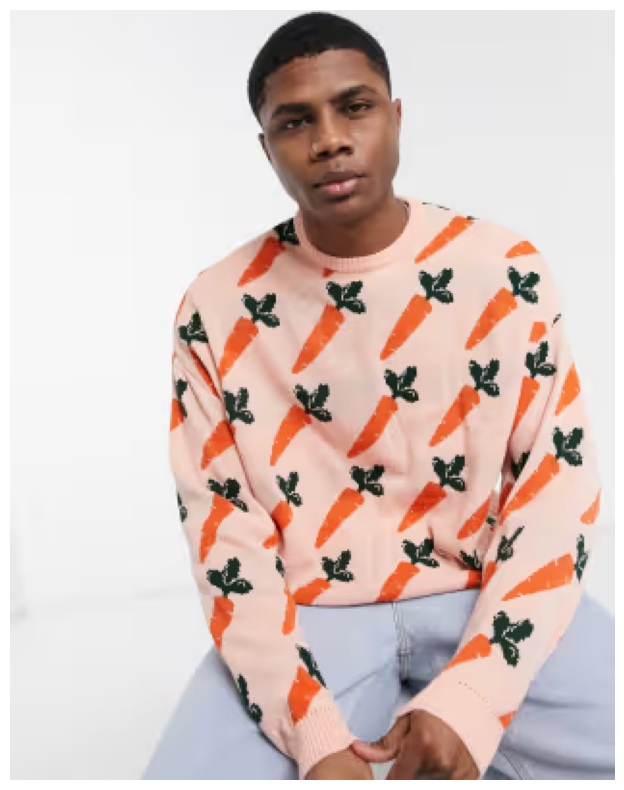

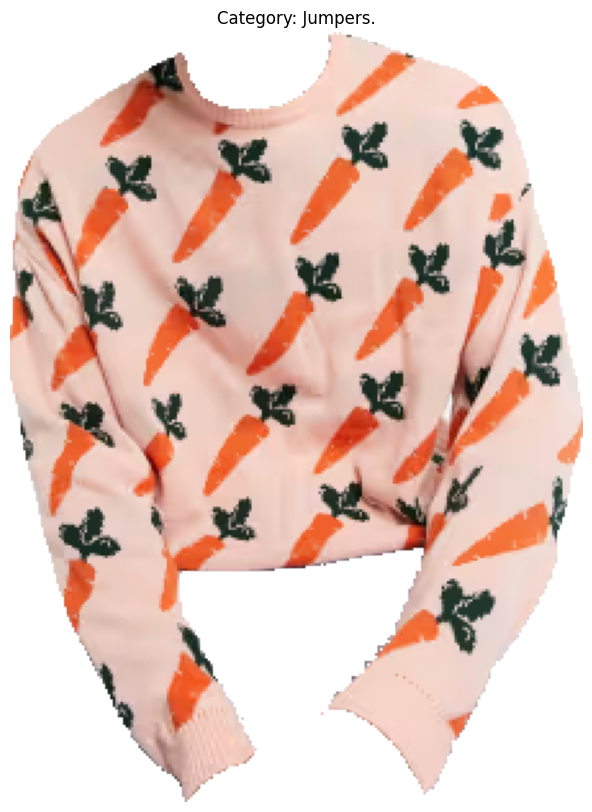

🔹 Loading OpenCLIP model...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

[array([[-6.79016113e-04,  7.03125000e-02, -1.67236328e-02,
          1.42822266e-02, -3.58886719e-02, -1.03759766e-02,
         -1.70898438e-02, -1.84326172e-02, -6.01196289e-03,
          2.31933594e-02, -5.81054688e-02, -3.66210938e-02,
         -3.00292969e-02, -1.79443359e-02,  4.24804688e-02,
          4.39453125e-02,  8.72802734e-03,  3.34472656e-02,
          3.22265625e-02, -8.23974609e-03, -1.51977539e-02,
         -3.88183594e-02, -1.68457031e-02, -1.53808594e-02,
         -3.75976562e-02, -3.68652344e-02,  2.57568359e-02,
         -3.32031250e-02,  3.54003906e-02,  5.93261719e-02,
         -1.03027344e-01,  1.86767578e-02,  2.55126953e-02,
         -2.84423828e-02,  1.03149414e-02, -2.25830078e-02,
         -9.53674316e-04, -4.12597656e-02, -6.83593750e-02,
         -8.05664062e-03,  2.17285156e-02, -3.68652344e-02,
          8.69140625e-02, -1.29394531e-02, -7.56835938e-02,
          2.22167969e-02, -4.32128906e-02,  3.88183594e-02,
         -2.99072266e-03, -3.46679688e-0

In [ ]:
from numpy._core.fromnumeric import prod
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import json
import io
from PIL import Image

# Session with retry strategy
session = requests.Session()
retries = Retry(
    total=3,
    backoff_factor=1,
    status_forcelist=[500, 502, 503, 504],
    allowed_methods=["GET"]
)
adapter = HTTPAdapter(max_retries=retries)
session.mount("https://", adapter)

# Realistic browser headers
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36",
    "Accept": "image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.asos.com/",       # crucial
    "Sec-Fetch-Dest": "image",
    "Sec-Fetch-Mode": "no-cors",
    "Sec-Fetch-Site": "cross-site",
}

# Optional: first visit ASOS homepage to get cookies
try:
    session.get("https://www.asos.com/", headers=HEADERS, timeout=(5, 10))
except Exception:
    print("Could not warm up session, continuing anyway...")

# Load your product data
test_path = "/content/raw/Jumpers.json"
with open(test_path, "r") as f:
    data = json.load(f)

product = data[0]
image_url = product["images"][0]
print(f"Fetching: {image_url}")
await generate_embedding(image_url=image_url, text=product["productType"], show_image=True, show_segment=True)

# # Try to download the image
# try:
#     # Connect timeout=10s, read timeout=20s (adjust as needed)
#     r = session.get(image_url, headers=HEADERS, timeout=(10, 20))
#     r.raise_for_status()
#     print(f"HTTP {r.status_code} - Content length: {len(r.content)}")

#     image = Image.open(io.BytesIO(r.content))
#     image.show()   # or just `image` in Jupyter
#     plt.imshow(image)
#     plt.axis('off')
#     plt.show()
# except requests.exceptions.ReadTimeout:
#     print("Read timed out – the server did not respond in time. "
#           "Possible causes: expired URL, missing Referer, or geo‑block. "
#           "Try opening the URL manually in a browser to check validity.")
# except Exception as e:
#     print(f"Other error: {e}")

In [ ]:
import json
import glob
import httpx
import io
import traceback
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm   # <-- auto: best display (widget in Jupyter, bar in terminal)

API_URL = "https://fitfinder-ai-service.hf.space/api/v1/faiss/add-embedding"

# Safe dict helper
def safe_get(d, key, default=None):
    val = d.get(key, default)
    return val if val is not None else default

async def process_asos_items():
    print("📌 Processing ASOS JSON files...")

    # # Load FAISS indexes into memory (only once)
    # load_faiss_indexes()

    # wrap everything so we can save on interrupt
    try:
        # Outer bar: files
        for file_path in tqdm(glob.glob(RAW_DATA_PATH), desc="Files", unit="file"):
            products_succeeded = 0
            products_failed = 0

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            products = data if isinstance(data, list) else [data]

            # Inner bar: products (leave=False so it disappears after file is done)
            product_iter = tqdm(products, desc=f"📦 {Path(file_path).name}",
                                unit="prod", leave=False)
            for idx, product in enumerate(product_iter):
                web_url = safe_get(product, "url", "")
                if not web_url:
                    products_failed += 1
                    continue

                # Resume check – skip already stored products
                if product_already_exists(web_url):
                    products_succeeded += 1
                    continue

                image_urls = product.get("images", [])
                if not image_urls:
                    products_failed += 1
                    continue

                # Prepare metadata (None-safe)
                title = truncate(safe_get(product, "name", ""))
                price = float(safe_get(product, "currentPrice", -1.0))
                currency = truncate(safe_get(product, "currency", ""))
                category = (safe_get(product, "productType") or
                            file_path.split("/")[-1].split(".")[0] or
                            safe_get(product, "brand", "unknown"))
                description = safe_get(product, "name", "")
                source = truncate(safe_get(product, "provider", ""))

                # First image must succeed, else skip product
                first_image = image_urls[0]
                first_embeddings = await generate_embedding(first_image, category)
                if first_embeddings is None:
                    failed_products.append(first_image)
                    products_failed += 1
                    continue

                item_id = insert_item_metadata(
                    title=title,
                    price=price,
                    currency=currency,
                    item_web_url=truncate(web_url),
                    image_url=truncate(first_image),
                    category=truncate(category),
                    description=description,
                    source=source
                )

                # Add embeddings to FAISS (in‑memory)
                for emb in first_embeddings:
                  # 1. Prepare the payload (ensure the embedding is a list of floats/ints)
                  payload = {"embedding": emb if isinstance(emb, list) else emb.tolist()}

                  try:
                      # 2. Make the POST request
                      response = requests.post(API_URL, json=payload)
                      response.raise_for_status()  # Raises an error for 4xx or 5xx status codes

                      # 3. Extract the faiss_id from the response
                      # (Assuming the API returns JSON like {"faiss_id": "some_id"} or similar)
                      response_data = response.json()
                      faiss_id = response_data.get("faiss_id")

                      # 4. Continue with your local database/tracking operations
                      add_FIASS(item_id, faiss_id)
                      insert_product_image(item_id, first_image, faiss_id)

                  except requests.exceptions.RequestException as e:
                      print(f"API Error for item {item_id}: {e}")

                # Process remaining images
                for img_idx, image_url in enumerate(image_urls[1:], start=1):
                    embeddings = await generate_embedding(image_url, category)
                    if embeddings is None:
                        failed_products.append(image_url)
                        continue
                    for emb in embeddings:
                        faiss_id = add_embedding(emb, index_type="stored_item")
                        add_FIASS(item_id, faiss_id)
                        # insert_product_image(item_id, image_url, faiss_id)  # optional

                products_succeeded += 1

                # 💾 Save FAISS every 100 products (safety checkpoint)
                if products_succeeded % 100 == 0:
                    save_faiss_indexes()

            # End of current file
            tqdm.write(f"   ✅ {Path(file_path).name}: {products_succeeded} succeeded, {products_failed} failed")
            # 💾 Save after every file
            save_faiss_indexes()

    finally:
        # 🔒 Always run, even on KeyboardInterrupt / Stop button
        print("\n🧹 Saving FAISS indexes and closing connections...")
        save_faiss_indexes()
        await http_client.aclose()
        DB_POOL.closeall()

    # Write failed URLs if any
    if failed_products:
        with open("failed_products.json", "w") as f:
            json.dump(failed_products, f, indent=2)
        print(f"⚠ {len(failed_products)} failed image URLs written to failed_products.json")
    else:
        print("🎉 All images processed successfully!")

In [ ]:
await process_asos_items()

📌 Processing ASOS JSON files...
Creating new FAISS index: /faiss_indexes/faiss_uploaded_imgs.index
Creating new FAISS index: /faiss_indexes/faiss_stored_items.index


Files:   0%|          | 0/90 [00:00<?, ?file/s]

📦 Jumpers.json:   0%|          | 0/289 [00:00<?, ?prod/s]

   ✅ Jumpers.json: 289 succeeded, 0 failed
Saved FAISS index: /faiss_indexes/faiss_uploaded_imgs.index
Saved FAISS index: /faiss_indexes/faiss_stored_items.index


📦 Caps.json:   0%|          | 0/12 [00:00<?, ?prod/s]

...

📦 Boxers.json:   0%|          | 0/8 [00:00<?, ?prod/s]

   ✅ Boxers.json: 8 succeeded, 0 failed
Saved FAISS index: /faiss_indexes/faiss_uploaded_imgs.index
Saved FAISS index: /faiss_indexes/faiss_stored_items.index


📦 Socks.json:   0%|          | 0/18 [00:00<?, ?prod/s]

   ✅ Socks.json: 18 succeeded, 0 failed
Saved FAISS index: /faiss_indexes/faiss_uploaded_imgs.index
Saved FAISS index: /faiss_indexes/faiss_stored_items.index


📦 Shoes.json:   0%|          | 0/251 [00:00<?, ?prod/s]

In [ ]:
# await process_items()

In [ ]:
len(failed_products)

# Test new Segment method

In [ ]:
!mkdir -p images
!wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/truck.jpg
!wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/groceries.jpg
!wget -P images https://res.cloudinary.com/dsjkgv4v2/image/upload/v1761834324/677e5c5f-5557-44ab-b3e2-26cf0c2bf4c6.png


## Test 1

In [ ]:
image = Image.open("images/2a1401e8afc099188ceed5a3094fbdb5.jpg").convert('RGB')

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "clothes.".lower())

print(masks.shape)
print(scores.shape)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

## Test 2

In [ ]:
image = Image.open("images/60s-fashion-239795-1562148964723-main.jpg").convert('RGB')

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "clothes. shoe. shirt. glove. pants. boot. Men's suit. suit.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
image = Image.open("images/images.jpg").convert('RGB')

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "clothes. shoe. shirt.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
print(masks[0][0])

In [ ]:
print(np.max(masks[0][0]))
print(np.max(sam.squeeze_mask(np.squeeze(masks, axis=1))))

In [ ]:
Y = sam.squeeze_mask(np.squeeze(masks, axis=1))

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(Y, cmap="viridis")
plt.colorbar(label="Accumulated mask value")
plt.title("Weighted Mask Projection (Y)")
plt.axis("off")
plt.show()

In [ ]:
image = Image.open("images/img8.jpg").convert('RGB')

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "clothes. shoe. shirt. glove. pants. boot.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
image = Image.open("images/img9.jpg").convert('RGB')

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "clothes.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, " shoe.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "shirt.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "glove.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "pants.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "boot.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "Men's suit.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "suit.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)

In [ ]:
masks , boxes, scores= sam.segment_with_prompt(image, "Women's suit.".lower())

print(masks.shape)
print(scores.shape)
print(boxes)
print(scores)

show_masks(image,
      masks,
      scores,
      box_coords=boxes,
      borders=False)